In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

import awkward as ak
import coffea
from coffea.nanoevents import NanoEventsFactory, BaseSchema, NanoAODSchema
from coffea.nanoevents.methods import candidate
from coffea.dataset_tools import apply_to_fileset, max_chunks, max_files, preprocess

from coffea import processor
from coffea.processor.accumulator import column_accumulator
from helpers import gen_higgs_parentage

import dask
import uproot

import json
import pickle
import xgboost as xgb

In [ ]:
class BDTFeatureExtractor(processor.ProcessorABC):
    def __init__(self, signal_label="signal", background_label="background"):
        self.signal_label = signal_label
        self.background_label = background_label


    def process(self, events):
        dataset = events.metadata.get('short_name', 'unknown')
        is_signal = events.metadata.get('isSignal', False)

        jets = events.Jet[events.Jet.pt > 20]        
        b_jets = jets[jets.btagPNetB > 0.0]
        muons = events.Muon

        parkingMuonMask = (muons.pt > 11) & (abs(muons.eta) < 0.9) 
        trigMuons = muons[(muons.triggerIdLoose) & parkingMuonMask]

        events=events[(events.HLT.Mu10_Barrel_L1HP11_IP6) & (ak.num(trigMuons) > 0)]


        # jetsWithTrigMuon = jets[trigMuons.delta_r(trigMuons.nearest(jets)) < 0.4]
        # trigMuonsInJet = jetsWithTrigMuon.nearest(trigMuons)
        # firstTrigMuonInJet = ak.firsts(trigMuonsInJet)

        pairs = ak.combinations(b_jets, 2, fields=["b1", "b2"])
        
        dijet = pairs.b1 + pairs.b2
        # sumjet_pt = pairs.b1.pt + pairs.b2.pt

        dijet_pt = dijet.pt
        dijet_eta = dijet.eta
        dijet_phi = dijet.phi
        
        jet_1 = pairs.b1;                    jet_2 = pairs.b2
        jet1_pt = jet_1.pt;                  jet2_pt = jet_2.pt
        jet1_eta = jet_1.eta;                jet2_eta = jet_2.eta    
        jet1_phi = jet_1.phi;                jet2_phi = jet_2.phi
        jet1_btag = jet_1.btagPNetB;         jet2_btag = jet_2.btagPNetB

        jet1_dR_trigMu = jet_1.delta_r(jet_1.nearest(trigMuons))
        jet2_dR_trigMu = jet_2.delta_r(jet_2.nearest(trigMuons))

        if is_signal:
            jet1_flav = jet_1.hadronFlavour;  jet2_flav = jet_2.hadronFlavour
            bbarmask = (((jet1_flav - jet2_flav) == 0) & (abs(jet1_flav) == 5))
        
        delta_phi = jet_1.delta_phi(jet_2)
        delta_r = jet_1.delta_r(jet_2)
        

        features = {
            'dijet_pt': ak.flatten(dijet_pt), 'dijet_eta': ak.flatten(dijet_eta), 'dijet_phi': ak.flatten(dijet_phi),
            # 'dijet_pt': ak.flatten(sumjet_pt), 'dijet_eta': ak.flatten(dijet_eta), 'dijet_phi': ak.flatten(dijet_phi),
            'jet1_pt': ak.flatten(jet1_pt), 'jet2_pt': ak.flatten(jet2_pt),
            'jet1_eta': ak.flatten(jet1_eta), 'jet2_eta': ak.flatten(jet2_eta),
            'jet1_phi':     ak.flatten(jet1_phi), 'jet2_phi': ak.flatten(jet2_phi),
            'jet1_btag': ak.flatten(jet1_btag), 'jet2_btag': ak.flatten(jet2_btag),
            'jet1_dR_trigMu': ak.flatten(jet1_dR_trigMu), 'jet2_dR_trigMu': ak.flatten(jet2_dR_trigMu),            
            'delta_phi': ak.flatten(delta_phi), 'delta_r': ak.flatten(delta_r),
        } 

        dijet_array = ak.flatten(dijet_pt)
        total_pairs = ak.num(dijet_array, axis=0)
        n_events = ak.num(events, axis=0)

        if is_signal:
            labels_flat = ak.values_astype(ak.flatten(bbarmask), np.int32)
        else:        
            labels_flat = ak.zeros_like(dijet_array)
        
        return {
            'features': {k: column_accumulator(v) for k, v in features.items()},
            'labels': column_accumulator(labels_flat),
            'n_events': n_events,
            'n_pairs': total_pairs,
        }
    
    def postprocess(self, accumulator):
        pass


In [21]:
def numpyify(output_dict):
    feature_arrays = []
    label_arrays = []

    feature_names = [
        'dijet_pt', 'dijet_eta', 'dijet_phi',
        'jet1_pt', 'jet2_pt', 
        'jet1_eta', 'jet2_eta',
        'jet1_phi', 'jet2_phi',
        'jet1_btag', 'jet2_btag',
        'jet1_dR_trigMu', 'jet2_dR_trigMu',
        'delta_phi', 'delta_r',
    ]

    features = output_dict['features']
    labels = output_dict['labels']
    
    feature_array = np.column_stack([ak.to_numpy(features[name].value) for name in feature_names])
    
    label_array = ak.to_numpy(labels.value)        
    feature_arrays.append(feature_array)
    label_arrays.append(label_array)
    
    X = np.vstack(feature_arrays)
    y = np.hstack(label_arrays)
    
    return X, y, feature_names


In [30]:
signal_fileset = {"/Private/HiggsToBB/ggF/Sum24_1mil_ggF": 
 {
    "files": {"./signal_Sum24_1mil_ggF.root": "Events"},
    "metadata": {"isSignal": True, "isMC": True,"short_name": "signalggF"}
 }
}

background_fileset = {"/Private/HiggsToBB/QCD/Sum24_1mil_QCD": 
   {
    "files": {"./background_Sum24_1mil_QCD.root": "Events"},
    "metadata": {"isSignal": False, "isMC": True,"short_name": "backgroundQCD"}
   }
}
# background_fileset = {"/ParkingSingleMuon0/Run2024B-PromptReco-v1/NANOAOD": 
#  {
#     "files": {
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/981/00000/9bc5764d-1d22-41d1-ac50-52a16aab6242.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/985/00000/a1bac08b-a0fc-4bbf-976c-7ebbc86d4ef0.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/993/00000/ebfeb1a1-ffbd-4287-bb0b-da4655a2ed32.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/994/00000/66edd28e-e731-4615-a79e-53c6e70dab34.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/995/00000/5ef0f348-3e71-4f87-a858-8902a0009e89.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/996/00000/4388bd63-3c16-40eb-8ee9-b544b0fb2292.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/997/00000/fb50fe91-0a48-46f9-a932-53945b4e4a25.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/998/00000/9aaad93f-2956-4a86-b114-a4dd384fbed3.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/999/00000/64ff3414-b1f4-4f24-8f02-75af115e715e.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/000/00000/fe64c7e3-4a8e-4cf0-9f14-099ea51bf3e8.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/001/00000/933fb5c5-1bfd-471f-b51e-7d065f3a03c7.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/002/00000/c9a51298-009b-43c6-9abd-2c688a0fcee7.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/003/00000/850233be-723e-4dc7-9f68-0e3c96b01100.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/004/00000/013edca2-be7d-4390-b70b-2a25d4982ce4.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/005/00000/56e4b734-c67d-44f4-acee-d47f625523a2.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/006/00000/7c84a04d-2e82-4308-a48d-249c96d17829.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/007/00000/d97a316f-3792-4dda-9df3-e4d7693c6657.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/008/00000/9e3cc8dc-517c-42cc-bfe9-cac5b155bfdf.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/009/00000/663bb252-f54f-40d8-91b3-8f46f24213c5.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/010/00000/2365ccf1-432b-4bf4-b9e5-d2f470d780fa.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/011/00000/9bdb1d35-f0db-4899-9926-21a543ec5f8d.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/012/00000/7029456c-1e08-4c9f-b687-7019d0e8cf73.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/028/00000/bd9a1dd3-046b-4fdc-baae-213b1a9660f7.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/029/00000/ea19ba07-1b6c-48e9-80e8-934956a79e6c.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/031/00000/b941ae56-3d13-4c11-b5b2-d4cf0a8e738f.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/058/00000/75ab83c1-9b9f-4892-8c47-15b1c86691f9.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/075/00000/49eab3d4-3283-447b-9f53-02d1045134a6.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/154/00000/894bd188-ded2-4a47-8e5a-a835274a451d.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/238/00000/aa550ca3-4c6e-4595-8fa0-7de4039088f3.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/243/00000/4bc1d91a-8240-4d2f-a7a0-2df3a0615540.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/252/00000/0b6f4bcc-877c-4ee7-bf50-1ba0e30d7175.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/252/00000/9d7348e8-596d-47db-b541-85904ece1ca0.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/253/00000/67d395fb-8fb8-4191-b621-29c28d42ac3e.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/338/00000/41042ef4-8802-48b4-b664-a233be09f2ef.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/349/00000/43e07ad6-2b15-4b25-90b5-5c7de7bcb92e.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/350/00000/e023d2ed-81bf-4fda-b80e-6256f689f622.root": "Events",
#       "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/355/00000/59543a9d-e235-4e95-8a05-9fea635d22be.root": "Events"
#     },
#     "metadata": {"isSignal": False, "isMC": False, "short_name": "SingleMuon24B0"}
#   }
# }

training_fileset = signal_fileset | background_fileset

In [28]:
#fn= "signal_Sum24_1mil_ggF.root:Events"
fn= "background_Sum24_1mil_QCD.root:Events"
# events = NanoEventsFactory.from_root(fn, schemaclass=NanoAODSchema, entry_start=0, entry_stop=1000, mode="eager").events()


jets = events.Jet[events.Jet.pt > 20] 
gens = events.GenJet
trigs = events.TrigObj
muons = events.Muon


parkingMuonMask = (muons.pt > 11) & (abs(muons.eta) < 0.9) 
trigMuons = muons[(muons.triggerIdLoose) & parkingMuonMask]
events=events[(events.HLT.Mu10_Barrel_L1HP11_IP6) & (ak.num(trigMuons) > 0)]

pairs = ak.combinations(jets, 2, fields=["b1", "b2"])  
dijet = pairs.b1 + pairs.b2
        
jet_1 = pairs.b1; jet_2 = pairs.b2

jet1_dR_trigMu = jet_1.delta_r(jet_1.nearest(trigMuons))
jet2_dR_trigMu = jet_2.delta_r(jet_2.nearest(trigMuons))
        


print(len(ak.flatten(trigMuons.nearest(jets))))
print(ak.flatten(trigMuons.delta_r(trigMuons.nearest(jets))))

jetsWithTrigMuon = jets[trigMuons.delta_r(trigMuons.nearest(jets)) < 0.4]

trigMuonsInJet = jetsWithTrigMuon.nearest(trigMuons)


print(len(ak.flatten(trigMuonsInJet)))
# print(len(trigMuonsInJets[0]))

# ak.flatten(jets.delta_r(jets.nearest(trigMuons)))
# print(ak.flatten(deltaRClosest))


# mAndJ = ak.cartesian([jets, trigMuons], axis = 0)

# muonyJet = jets[ak.any(mAndJ)]

# print(muonsAndJets[0])

# ak.drop_none(ak.firsts(trigs[trigs.id == 13]).delta_r(jets))


# print(ak.flatten(trigs.pt[events.HLT.Mu10_Barrel_L1HP11_IP6]))
# print(ak.flatten(events.TrigObj))

23
[0.816, 0.0654, 0.0963, 0.0492, 0.0792, ..., 0.0591, 0.0865, 0.05, 0.0495, 3.08]
21


In [109]:
fn= "higgs125_bb_ggF_v15.root:Events"
events = NanoEventsFactory.from_root(fn, schemaclass=NanoAODSchema, entry_start=0, entry_stop=1000, mode="virtual").events()

In [357]:
def gen_higgs_parentage(events):
    is_higgs = abs(events.GenPart.pdgId) == 25
    current_mask = is_higgs
    mother_indices = events.GenPart.genPartIdxMother
    
    while ak.any(mother_indices >= 0):
        has_mother = mother_indices >= 0
        mother_is_higgs = ak.fill_none(ak.mask(is_higgs[mother_indices], has_mother), False)

        current_mask = current_mask | mother_is_higgs
        mother_indices = ak.fill_none(ak.mask(events.GenPart.genPartIdxMother[mother_indices], has_mother), -1 )
    
    GenPart = ak.with_field(events.GenPart, current_mask, where="fromHiggs")
    return GenPart
    
gens = gen_higgs_parentage(events)
bgens = gens[(abs(gens.pdgId) == 5)]
bgens_higgs = bgens[bgens.fromHiggs]

jets = events.Jet
bjets = jets[abs(jets.partonFlavour) == 5]
bjet_with_bgens = bjets[bjets.partonFlavour - bjets.nearest(bgens_higgs).pdgId == 0]

parton_dr = bjet_with_bgens.delta_r(bjet_with_bgens.nearest(bgens_higgs))
parton_matched = parton_dr < 0.4

matched_jets = ak.with_field(bjet_with_bgens, parton_matched, where="matchedToHiggs")
print(len(ak.flatten(matched_jets)))


1661


In [ ]:
# Preprocessing
filename = f"preprocs/training_preprocessed.coffea"
if os.path.exists(filename):
    print(f"Loading preprocessed from {filename}...")
    with open(filename, "rb") as f:
        preprocessed_available = pickle.load(f)
else:
    print("Preprocessing...")
    preprocessed_available, preprocessed_total = preprocess(
            training_fileset,
            step_size=100_000,
            align_clusters=None,
            skip_bad_files=True,
            recalculate_steps=False,
            files_per_batch=1,
            file_exceptions=(OSError,),
            save_form=True,
            uproot_options={},
            step_size_safety_factor=0.5,
        )
    print(f"Saved to {filename}")
    with open(filename, "wb") as f:
        pickle.dump(preprocessed_available, f)

Loading preprocessed from preprocs/training_preprocessed.coffea...


In [31]:
iterative_run = processor.Runner(
    executor=processor.IterativeExecutor(compression=None),
    schema=NanoAODSchema,
    maxchunks=3,
    savemetrics=True,
)

out, metrics = iterative_run(
    training_fileset,
    processor_instance=BDTFeatureExtractor(),
)

X, y, feature_names = numpyify(out)
print(f"signal candidates: {np.sum(y == 1)}")
print(f"background candidates: {np.sum(y == 0)}")
print(f'{X.shape[1]} features = {feature_names}')

Output()

Output()

signal candidates: 118838
background candidates: 164878
15 features = ['dijet_pt', 'dijet_eta', 'dijet_phi', 'jet1_pt', 'jet2_pt', 'jet1_eta', 'jet2_eta', 'jet1_phi', 'jet2_phi', 'jet1_btag', 'jet2_btag', 'jet1_dR_trigMu', 'jet2_dR_trigMu', 'delta_phi', 'delta_r']


In [132]:
tg, rep = apply_to_fileset(
    data_manipulation=BDTFeatureExtractor(),
    fileset=preprocessed_available,
    schemaclass=NanoAODSchema,
    uproot_options={"allow_read_errors_with_report": (OSError, KeyError)},
)
# out = BDTFeatureExtractor().process(events)
out, rep = dask.compute(tg, rep)
for i in out.items():
    print(i)

X, y, feature_names = numpyify(out)
print(f"signal candidates: {np.sum(y == 1)}")
print(f"background candidates: {np.sum(y == 0)}")
print(f'{X.shape[1]} features = {feature_names}')

ValueError: column_accumulator only works with numpy arrays or awkward arrays

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training on {len(X_train)} dijets")
print(f"Testing on {len(X_test)} dijets")

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 4,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'gamma': 0.1,
    'random_state': 42,
    'tree_method': 'hist'
}
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

print("Starting training ...")
model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=xgb_params['n_estimators'],
    evals=[(dtrain, 'train'), (dtest, 'test')],
    early_stopping_rounds=10,
    verbose_eval=10,
)

Training on 226972 dijets
Testing on 56744 dijets
Starting training ...


/uscms/home/ccosby/.local/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [10:22:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	train-auc:0.73630	test-auc:0.73455
[10]	train-auc:0.76766	test-auc:0.76757
[20]	train-auc:0.77396	test-auc:0.77337
[30]	train-auc:0.77743	test-auc:0.77688
[40]	train-auc:0.78176	test-auc:0.78108
[50]	train-auc:0.78515	test-auc:0.78415
[60]	train-auc:0.78801	test-auc:0.78677
[70]	train-auc:0.78944	test-auc:0.78770
[80]	train-auc:0.79065	test-auc:0.78852
[90]	train-auc:0.79185	test-auc:0.78939
[100]	train-auc:0.79287	test-auc:0.79008
[110]	train-auc:0.79361	test-auc:0.79046
[120]	train-auc:0.79463	test-auc:0.79110
[130]	train-auc:0.79527	test-auc:0.79129
[140]	train-auc:0.79586	test-auc:0.79152
[150]	train-auc:0.79660	test-auc:0.79189
[160]	train-auc:0.79719	test-auc:0.79215
[170]	train-auc:0.79778	test-auc:0.79236
[180]	train-auc:0.79831	test-auc:0.79254
[190]	train-auc:0.79907	test-auc:0.79296
[199]	train-auc:0.79964	test-auc:0.79314


test AUC: 0.7931


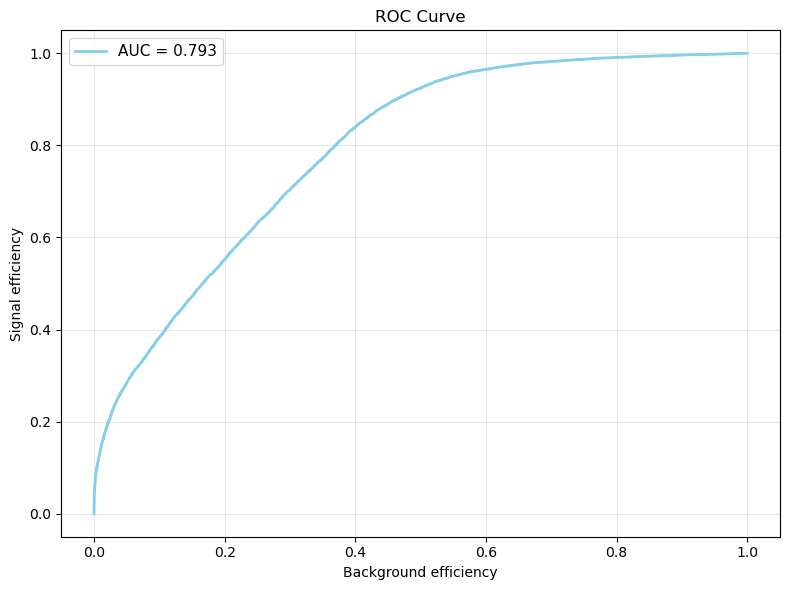

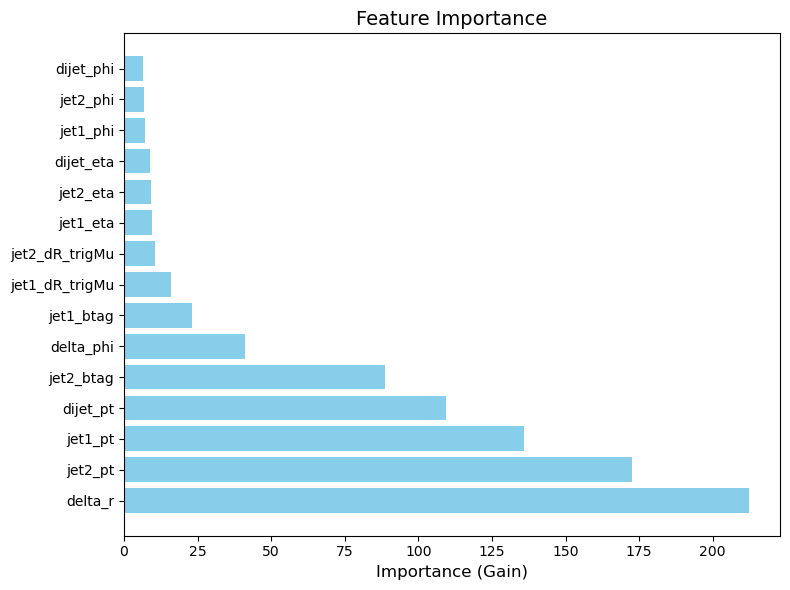

In [35]:
y_pred_test = model.predict(dtest)

auc_test = roc_auc_score(y_test, y_pred_test)
print(f"test AUC: {auc_test:.4f}")

fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, label=f'AUC = {auc_test:.3f}', linewidth=2, color='skyblue')
plt.xlabel('Background efficiency')
plt.ylabel('Signal efficiency')
plt.title('ROC Curve')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

importance = model.get_score(importance_type='gain')
feature_importance = [(feature_names[int(k[1:])], v) for k, v in importance.items()]
feature_importance.sort(key=lambda x: x[1], reverse=True)

plt.figure(figsize=(8, 6))
features_sorted, importances_sorted = zip(*feature_importance)
plt.barh(range(len(features_sorted)), importances_sorted, color='skyblue')
plt.yticks(range(len(features_sorted)), features_sorted)
plt.xlabel('Importance (Gain)', fontsize=12)
plt.title('Feature Importance', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
model_filename = "models/bdt_model.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(model, f)


feature_dict = {'feature_names': feature_names, 'n_features': len(feature_names)}
feature_dump = "models/bdt_feature_names.pkl"
with open(feature_dump, 'wb') as f:
    pickle.dump(feature_dict, f)

NameError: name 'model' is not defined

In [1]:
import hist
import dask
from hist import Hist, NamedHist
from hist.dask import Hist as DaskHist
from coffea import processor

class DijetMakerBDT(processor.ProcessorABC):
    def __init__(self, xgbmodel):
        self.model = xgbmodel

    def process(self, events):
        dijet_hist = (Hist.new.Reg(100, 50, 350, name="dijetmass", label="$m_{jj}$ [GeV]").Reg(12, 0, 300, name="dijetpt", label="$p_{T}$ [GeV]").Reg(100, 0, 1, name="bdt", label="BDT score").Double())
        
        jets = events.Jet[events.Jet.pt > 20]        
        b_jets = jets[jets.btagPNetB > 0.0]
        
        pairs = ak.combinations(b_jets, 2, fields=["b1", "b2"])
                
        dijet = pairs.b1 + pairs.b2
        dijet_pt = dijet.pt
        dijet_eta = dijet.eta
        dijet_phi = dijet.phi
        dijet_mass = dijet.mass
        
        jet1 = pairs.b1;                    jet2 = pairs.b2
        jet1_pt = jet1.pt;                  jet2_pt = jet2.pt
        jet1_eta = jet1.eta;                jet2_eta = jet2.eta    
        jet1_phi = jet1.phi;                jet2_phi = jet2.phi
        jet1_btag = jet1.btagPNetB;         jet2_btag = jet2.btagPNetB

        delta_phi = jet1.delta_phi(jet2)
        delta_r = jet1.delta_r(jet2)
        

        features = np.stack(
            [
            ak.flatten(dijet_pt), ak.flatten(dijet_eta), ak.flatten(dijet_phi),
            ak.flatten(jet1_pt), ak.flatten(jet2_pt),
            ak.flatten(jet1_eta), ak.flatten(jet2_eta),
            ak.flatten(jet1_phi), ak.flatten(jet2_phi),
            ak.flatten(jet1_btag), ak.flatten(jet2_btag),
            ak.flatten(delta_phi), ak.flatten(delta_r),
            ], axis=-1
        )
        
        features = ak.to_numpy(features)
        dmatrix = xgb.DMatrix(features)
        scores = self.model.predict(dmatrix)
        dijet["score"] = ak.unflatten(scores, ak.num(dijet))

        
        dijet_hist.fill(
            dijetmass=ak.flatten(dijet_mass),
            dijetpt=ak.flatten(dijet_pt),
            bdt=ak.flatten(dijet.score),
        )


        return {
            "entries": ak.num(events, axis=0),
            "dijet_hist": dijet_hist
        }
    
    def postprocess(self, accumulator):
        pass

/usr/local/lib/python3.10/site-packages/ndcctools/taskvine/__init__.py:74: DaskVineWarning: ndcctools.taskvine.DaskVine only works with dask version >= 2024.12.0
  warnings.warn("ndcctools.taskvine.DaskVine only works with dask version >= 2024.12.0", DaskVineWarning)


In [7]:
iterative_run = processor.Runner(
    executor=processor.IterativeExecutor(compression=None),
    schema=NanoAODSchema,
    maxchunks=3,
    savemetrics=True,
)

out, metrics = iterative_run(
    signal_fileset,
    processor_instance=DijetMakerBDT(model),
)


NameError: name 'model' is not defined

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd3c7a4f190>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fd3d45b6d40>, text=[])

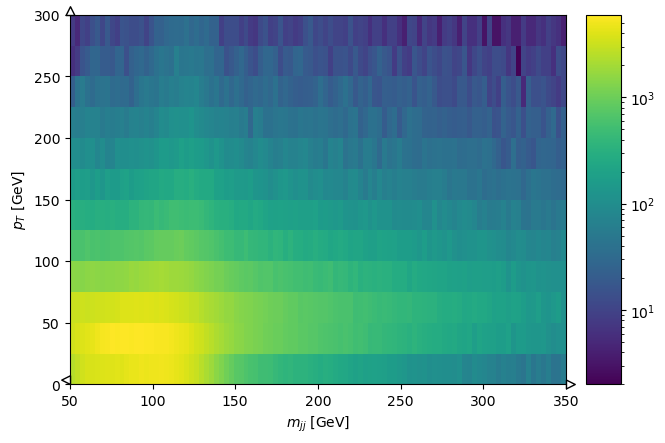

In [ ]:
import matplotlib.colors as colors
import matplotlib

hist_3d = out['dijet_hist']
# mass_projection = hist_3d[:, sum, 0j:0.1j:sum].plot1d()
bdt_projection = hist_3d[sum, sum, :].plot1d()



hist_2d.project("dijetmass", "dijetpt").plot2d(norm=matplotlib.colors.LogNorm())


# for i, axis in enumerate(hist_2d.axes):
#     fig, ax = plt.subplots(figsize=(10, 6)) 
#     hist_2d.project(axis.name).plot1d(ax=ax, fill=True, label=axis.name, color=plt.colormaps['Set1'](i), flow='none')
#     plt.show()